# Definition of Probability

This notebook covers the foundational concepts of probability theory:
- **Events and Experiments** — Sample Space, Events
- **Definition of Probability** — Frequentist (limit) definition
- **Axioms of Probability** — Kolmogorov's three axioms
- **Provable Identities** — Complement, subset properties

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Definition of Probability](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/probability/)

## Setup

Import necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import base64
import io
import requests
from PIL import Image as im

np.random.seed(42)

VERBOSE = True

## Mermaid Diagram Helper

Renders Mermaid diagrams using the [mermaid.ink](https://mermaid.ink) service via the `mm()` function.

See: [Jupyter/Python Integration with Mermaid](https://mermaid.ai/open-source/ecosystem/tutorials.html#jupyter-python-integration-with-mermaid-js)

In [2]:
def mm(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    img = im.open(io.BytesIO(requests.get('https://mermaid.ink/img/' + base64_string).content))
    plt.imshow(img)
    plt.axis('off')
    plt.savefig('image.png', dpi=1200)

### Venn Diagram Helper

Renders [Mermaid `venn-beta`](https://mermaid.js.org/syntax/venn.html) syntax using `matplotlib` patches (since `mermaid.ink` does not yet support `venn-beta`).

Imported from [`libs/venn.py`](../libs/venn.py). Full syntax reference: [`libs/venn_syntax_reference.ipynb`](../libs/venn_syntax_reference.ipynb).

Supported syntax:
```
venn-beta
  title "My Title"
  set A["Label A"]
    text a1["item"]
  set B["Label B"]
  union A,B["Overlap"]
  style A fill:#ff6b6b
```

In [3]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from libs.venn import venn

---

## 1. Events and Experiments

When we speak about probabilities, there is always an implied context — an **experiment**.

An experiment is any process that produces an observable result. To reason about probability precisely, we define two sets:
1. The **Sample Space** — all possible outcomes
2. An **Event** — a subset of the sample space we care about

### Sample Space $S$

> **Definition:** The Sample Space $S$ is the set of all possible outcomes of an experiment.

| Experiment | Sample Space $S$ |
|---|---|
| Coin flip | $\{\text{Heads}, \text{Tails}\}$ |
| Two coin flips | $\{(H,H), (H,T), (T,H), (T,T)\}$ |
| Roll of 6-sided die | $\{1, 2, 3, 4, 5, 6\}$ |

Coin flip sample space:      S = {'Heads', 'Tails'}
Two coin flips sample space: S = {('T', 'H'), ('T', 'T'), ('H', 'H'), ('H', 'T')}
Die roll sample space:       S = {1, 2, 3, 4, 5, 6}


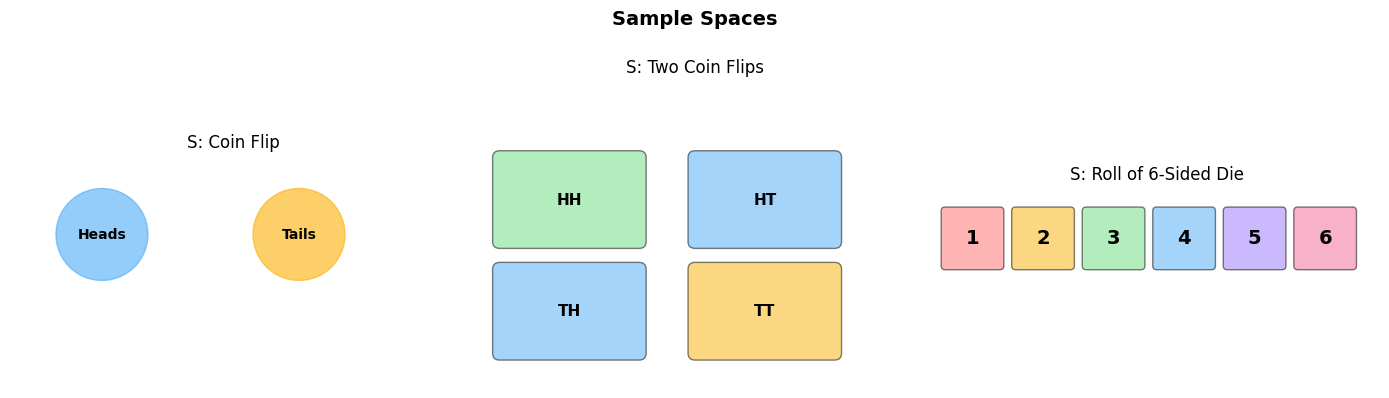

In [31]:
# Sample spaces as Python sets

# Coin flip
S_coin = {"Heads", "Tails"}
print(f"Coin flip sample space:      S = {S_coin}")

# Two coin flips
S_two_coins = {(a, b) for a in ["H", "T"] for b in ["H", "T"]}
print(f"Two coin flips sample space: S = {S_two_coins}")

# Roll of 6-sided die
S_die = {1, 2, 3, 4, 5, 6}
print(f"Die roll sample space:       S = {S_die}")

# --- Visualization: Sample Spaces ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Coin flip
for i, outcome in enumerate(["Heads", "Tails"]):
    color = "#4dabf7" if outcome == "Heads" else "#fab005"
    circle = plt.Circle((i * 1.5 + 0.5, 0.5), 0.35, color=color, alpha=0.6)
    axes[0].add_patch(circle)
    axes[0].text(i * 1.5 + 0.5, 0.5, outcome, ha='center', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(-0.2, 3.2)
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_title("S: Coin Flip", fontsize=12)
axes[0].set_aspect('equal')
axes[0].axis('off')

# Two coin flips
outcomes_2 = ["HH", "HT", "TH", "TT"]
colors_2 = ["#69db7c", "#4dabf7", "#4dabf7", "#fab005"]
for i, (outcome, c) in enumerate(zip(outcomes_2, colors_2)):
    row, col = divmod(i, 2)
    rect = patches.FancyBboxPatch((col * 1.4 + 0.1, (1 - row) * 0.8 + 0.05), 1.0, 0.6,
                                   boxstyle="round,pad=0.05", facecolor=c, alpha=0.5)
    axes[1].add_patch(rect)
    axes[1].text(col * 1.4 + 0.6, (1 - row) * 0.8 + 0.35, outcome, ha='center', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlim(-0.1, 3.1)
axes[1].set_ylim(-0.2, 2.0)
axes[1].set_title("S: Two Coin Flips", fontsize=12)
axes[1].set_aspect('equal')
axes[1].axis('off')

# Die roll
die_colors = ["#ff6b6b", "#fab005", "#69db7c", "#4dabf7", "#9775fa", "#f06595"]
for i, face in enumerate(range(1, 7)):
    rect = patches.FancyBboxPatch((i * 0.9 + 0.05, 0.2), 0.7, 0.7,
                                   boxstyle="round,pad=0.05", facecolor=die_colors[i], alpha=0.5)
    axes[2].add_patch(rect)
    axes[2].text(i * 0.9 + 0.4, 0.55, str(face), ha='center', va='center', fontsize=14, fontweight='bold')
axes[2].set_xlim(-0.1, 5.6)
axes[2].set_ylim(0.0, 1.2)
axes[2].set_title("S: Roll of 6-Sided Die", fontsize=12)
axes[2].set_aspect('equal')
axes[2].axis('off')

plt.suptitle("Sample Spaces", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Event $E$

> **Definition:** An Event $E$ is a subset of the sample space $S$ that we ascribe meaning to. In set notation: $E \subseteq S$.

| Experiment | Event Description | Event $E$ |
|---|---|---|
| Coin flip | Flip is heads | $\{\text{Heads}\}$ |
| Two coin flips | At least 1 head | $\{(H,H), (H,T), (T,H)\}$ |
| Die roll | Roll is 3 or less | $\{1, 2, 3\}$ |

Events are binary: they either happen or they don't.

Event 'heads':          E = {'Heads'}
  E ⊆ S ? True

Event 'at least 1 head': E = {('T', 'H'), ('H', 'H'), ('H', 'T')}
  E ⊆ S ? True

Event 'roll ≤ 3':       E = {1, 2, 3}
  E ⊆ S ? True


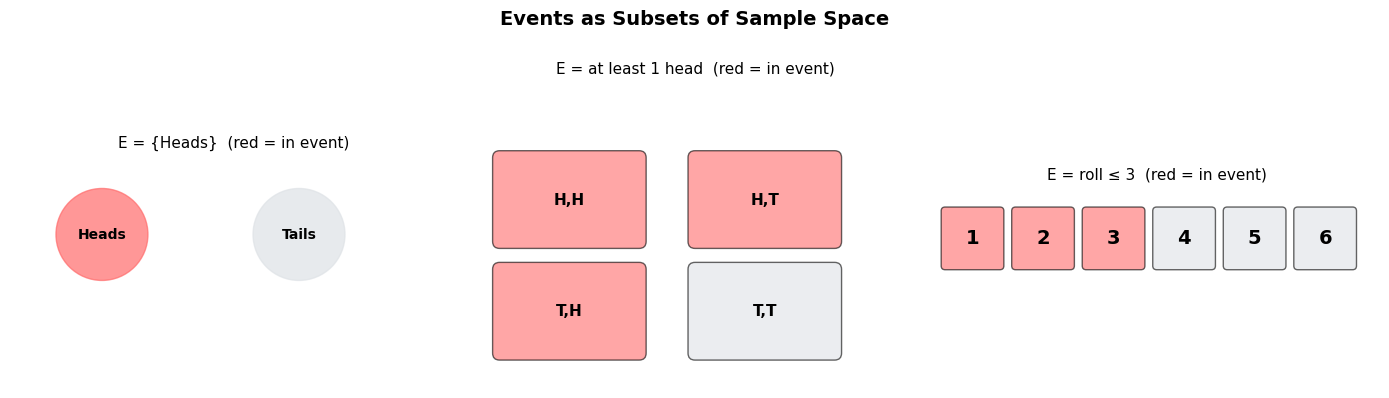

In [32]:
# Events as subsets of sample spaces

# Event: coin flip is heads
E_heads = {"Heads"}
print(f"Event 'heads':          E = {E_heads}")
print(f"  E ⊆ S ? {E_heads.issubset(S_coin)}")

# Event: at least 1 head in two flips
E_at_least_one_head = {(a, b) for a in ["H", "T"] for b in ["H", "T"] if a == "H" or b == "H"}
print(f"\nEvent 'at least 1 head': E = {E_at_least_one_head}")
print(f"  E ⊆ S ? {E_at_least_one_head.issubset(S_two_coins)}")

# Event: die roll is 3 or less
E_three_or_less = {1, 2, 3}
print(f"\nEvent 'roll ≤ 3':       E = {E_three_or_less}")
print(f"  E ⊆ S ? {E_three_or_less.issubset(S_die)}")

# --- Visualization: Events as highlighted subsets ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Coin flip: E = {Heads}
for i, outcome in enumerate(["Heads", "Tails"]):
    in_event = outcome in E_heads
    color = "#ff6b6b" if in_event else "#dee2e6"
    circle = plt.Circle((i * 1.5 + 0.5, 0.5), 0.35, color=color, alpha=0.7)
    axes[0].add_patch(circle)
    axes[0].text(i * 1.5 + 0.5, 0.5, outcome, ha='center', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(-0.2, 3.2)
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_title("E = {Heads}  (red = in event)", fontsize=11)
axes[0].set_aspect('equal')
axes[0].axis('off')

# Two coin flips: E = at least 1 head
outcomes_2 = [("H","H"), ("H","T"), ("T","H"), ("T","T")]
for i, outcome in enumerate(outcomes_2):
    in_event = outcome in E_at_least_one_head
    color = "#ff6b6b" if in_event else "#dee2e6"
    row, col = divmod(i, 2)
    rect = patches.FancyBboxPatch((col * 1.4 + 0.1, (1 - row) * 0.8 + 0.05), 1.0, 0.6,
                                   boxstyle="round,pad=0.05", facecolor=color, alpha=0.6)
    axes[1].add_patch(rect)
    label = f"{outcome[0]},{outcome[1]}"
    axes[1].text(col * 1.4 + 0.6, (1 - row) * 0.8 + 0.35, label, ha='center', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlim(-0.1, 3.1)
axes[1].set_ylim(-0.2, 2.0)
axes[1].set_title("E = at least 1 head  (red = in event)", fontsize=11)
axes[1].set_aspect('equal')
axes[1].axis('off')

# Die roll: E = {1, 2, 3}
for i, face in enumerate(range(1, 7)):
    in_event = face in E_three_or_less
    color = "#ff6b6b" if in_event else "#dee2e6"
    rect = patches.FancyBboxPatch((i * 0.9 + 0.05, 0.2), 0.7, 0.7,
                                   boxstyle="round,pad=0.05", facecolor=color, alpha=0.6)
    axes[2].add_patch(rect)
    axes[2].text(i * 0.9 + 0.4, 0.55, str(face), ha='center', va='center', fontsize=14, fontweight='bold')
axes[2].set_xlim(-0.1, 5.6)
axes[2].set_ylim(0.0, 1.2)
axes[2].set_title("E = roll ≤ 3  (red = in event)", fontsize=11)
axes[2].set_aspect('equal')
axes[2].axis('off')

plt.suptitle("Events as Subsets of Sample Space", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Venn Diagram: Sample Space and Event

The sample space $S$ contains all possible outcomes. An event $E$ is a subset within $S$.

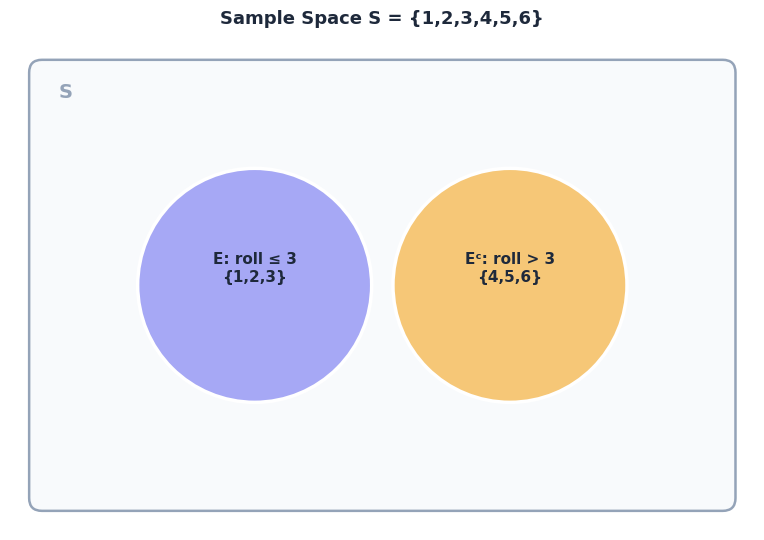

In [4]:
# Venn: Sample Space and Event
venn("""
venn-beta
  title "Sample Space S = {1,2,3,4,5,6}"
  set E["E: roll ≤ 3<br/>{1,2,3}"]
  set Ec["Eᶜ: roll > 3<br/>{4,5,6}"]
""")

---

## 2. Definition of Probability

The modern definition of probability is based on the **frequentist** (limit) interpretation:

$$P(E) = \lim_{n \to \infty} \frac{\text{count}(E)}{n}$$

Where:
- $n$ = number of trials of an experiment
- $\text{count}(E)$ = number of trials where event $E$ occurred
- As $n \to \infty$, the ratio converges to the true probability

**Key insight:** $P(E)$ is a measure of the chance of event $E$ occurring.

### Example: Dice Rolling Simulation

Event $E$: Rolling a 5 or 6 on a fair six-sided die.

The true probability is $P(E) = \frac{2}{6} = 0.\overline{3}$

Let's verify this converges as $n \to \infty$.

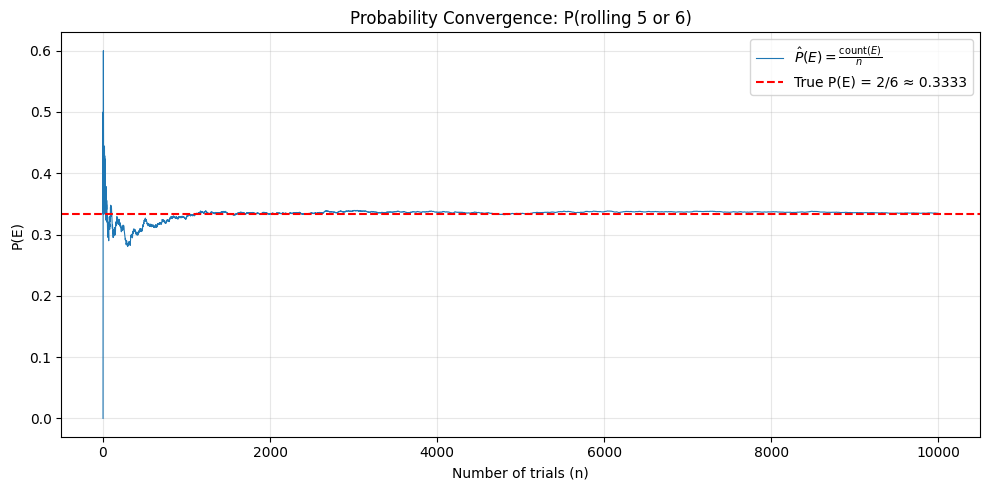

After 10,000 trials: P(E) ≈ 0.3346
True probability:        P(E) = 0.3333


In [34]:
# Simulate rolling a die many times and track P(E) convergence
n_trials = 10_000
rolls = np.random.randint(1, 7, size=n_trials)

# Event E: rolling a 5 or 6
event_occurred = (rolls == 5) | (rolls == 6)
cumulative_count = np.cumsum(event_occurred)
trial_numbers = np.arange(1, n_trials + 1)
running_probability = cumulative_count / trial_numbers

true_prob = 2 / 6

plt.figure(figsize=(10, 5))
plt.plot(trial_numbers, running_probability, linewidth=0.8, label=r"$\hat{P}(E) = \frac{\mathrm{count}(E)}{n}$")
plt.axhline(y=true_prob, color="red", linestyle="--", linewidth=1.5, label=f"True P(E) = 2/6 ≈ {true_prob:.4f}")
plt.xlabel("Number of trials (n)")
plt.ylabel("P(E)")
plt.title("Probability Convergence: P(rolling 5 or 6)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"After {n_trials:,} trials: P(E) ≈ {running_probability[-1]:.4f}")
print(f"True probability:        P(E) = {true_prob:.4f}")

### Probability from Data

> **Problem:** What is the probability a newborn elephant child is male?
>
> Data: 3,070 elephants born in Myanmar, of which 2,180 were male.  
> Source: [Animal Reproductive Science](https://www.sciencedirect.com/science/article/pii/S0378432008004442)

$$P(\text{Born Male}) = P(E) = \lim_{n \to \infty} \frac{\text{count}(E)}{n} \approx \frac{2{,}180}{3{,}070} \approx 0.710$$

Experiment: A single elephant birth in Myanmar
Sample space S = {Male, Female, Intersex}
Event E = {Male}

P(Born Male) = count(E) / n = 2,180 / 3,070 ≈ 0.710


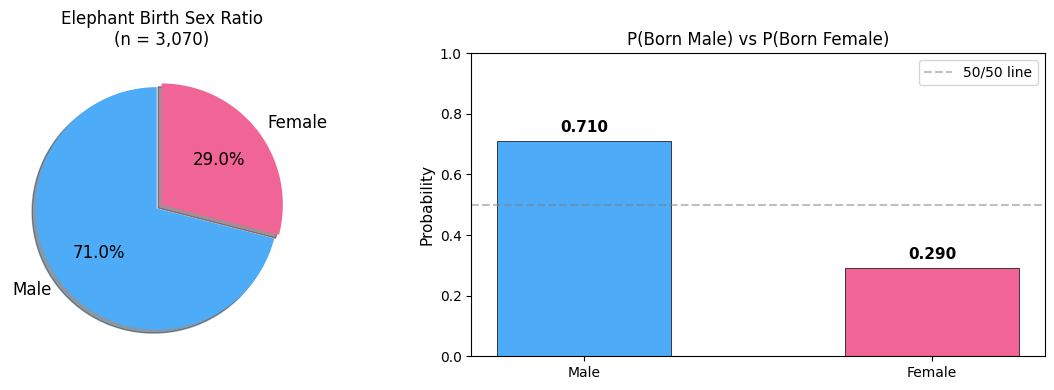

In [35]:
# Calculating probability from data
total_births = 3_070
male_births = 2_180
female_births = total_births - male_births

p_male = male_births / total_births
print(f"Experiment: A single elephant birth in Myanmar")
print(f"Sample space S = {{Male, Female, Intersex}}")
print(f"Event E = {{Male}}")
print(f"")
print(f"P(Born Male) = count(E) / n = {male_births:,} / {total_births:,} ≈ {p_male:.3f}")

# --- Visualization: Elephant birth probability ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
labels = ["Male", "Female"]
sizes = [male_births, female_births]
colors = ["#4dabf7", "#f06595"]
explode = (0.05, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax1.set_title(f"Elephant Birth Sex Ratio\n(n = {total_births:,})", fontsize=12)

# Bar chart
bars = ax2.bar(labels, [p_male, 1 - p_male], color=colors, width=0.5, edgecolor='black', linewidth=0.5)
ax2.set_ylabel("Probability", fontsize=11)
ax2.set_title("P(Born Male) vs P(Born Female)", fontsize=12)
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50/50 line')
ax2.legend()
for bar, val in zip(bars, [p_male, 1 - p_male]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

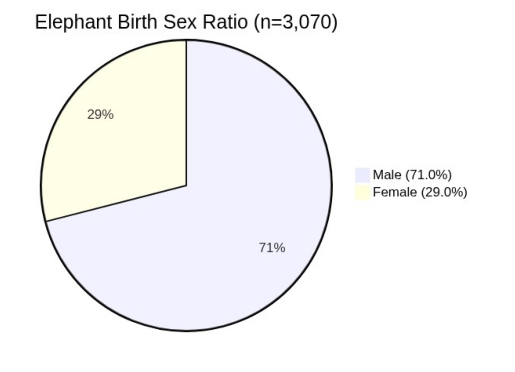

In [36]:
# Mermaid.js: Elephant birth sex ratio (pie chart)
mm("""
pie title Elephant Birth Sex Ratio (n=3,070)
    "Male (71.0%)" : 2180
    "Female (29.0%)" : 890
""")

### Origins of Probabilities

Probabilities can come from different sources:

| Origin | Description |
|---|---|
| **Analytical** | Calculated using mathematical proofs |
| **Empirical** | Calculated from data, experiments, or simulations |
| **Subjective** | Made up to represent a belief |
| **Combined** | A prior belief updated with data and evidence |

**Probabilities and percentages:** A percentage is simply a probability multiplied by 100. "Percent" is Latin for "out of one hundred."

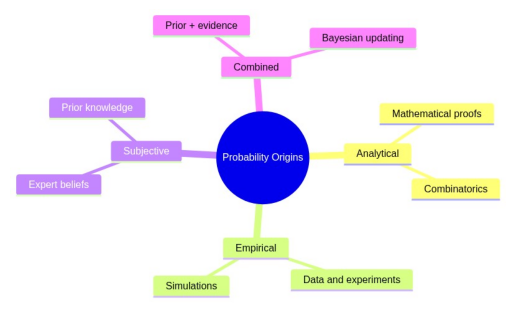

In [37]:
# Mermaid.js: Origins of Probability (mindmap)
mm("""
mindmap
  root((Probability Origins))
    Analytical
      Mathematical proofs
      Combinatorics
    Empirical
      Data and experiments
      Simulations
    Subjective
      Expert beliefs
      Prior knowledge
    Combined
      Prior + evidence
      Bayesian updating
""")

### Measuring Uncertainty

Probability is our robust language for expressing uncertainty.

Perhaps if you knew the position of every water molecule, you could perfectly predict tomorrow's weather. But we don't have such knowledge, so we use probability to express our belief that an event will happen **given our limited information**.

---

## 3. Axioms of Probability (Kolmogorov Axioms)

These three axioms are the foundation of all probability theory.

| Axiom | Statement | Meaning |
|---|---|---|
| **Axiom 1** | $0 \leq P(E) \leq 1$ | All probabilities are between 0 and 1 |
| **Axiom 2** | $P(S) = 1$ | The probability of the entire sample space is 1 |
| **Axiom 3** | If $E$ and $F$ are mutually exclusive: $P(E \text{ or } F) = P(E) + P(F)$ | Additive rule for disjoint events |

### Axiom 1: $0 \leq P(E) \leq 1$

From the definition of probability:
- You cannot observe more events than trials → $P(E) \leq 1$
- You cannot observe fewer than 0 events → $P(E) \geq 0$

Axiom 1: 0 ≤ P(E) ≤ 1
────────────────────────────────────────
P(roll = 1) = 0.1663  ✓ in [0,1]
P(roll = 2) = 0.1673  ✓ in [0,1]
P(roll = 3) = 0.1646  ✓ in [0,1]
P(roll = 4) = 0.1670  ✓ in [0,1]
P(roll = 5) = 0.1681  ✓ in [0,1]
P(roll = 6) = 0.1668  ✓ in [0,1]

P(roll = 7) = 0.0000  (impossible event → 0)
P(roll ≥ 1) = 1.0000  (certain event → 1)


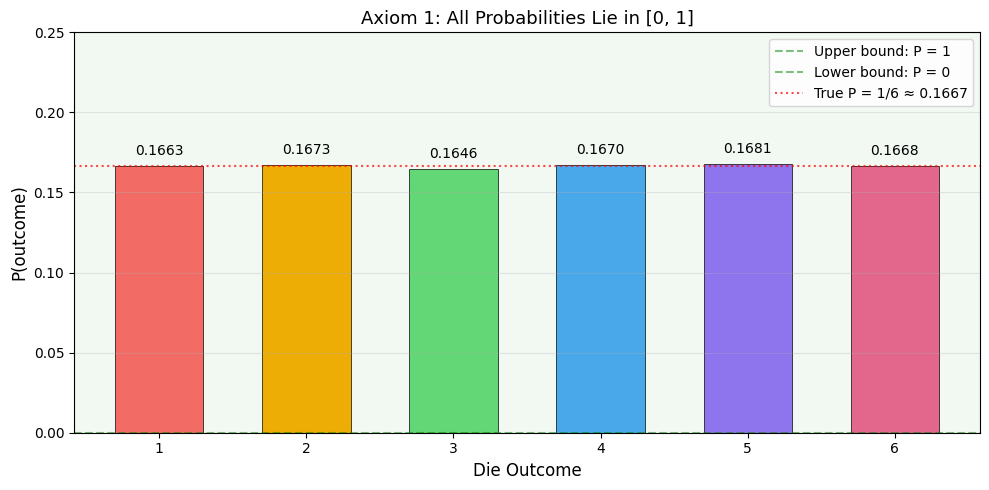

In [38]:
# Verify Axiom 1: all probabilities lie in [0, 1]
S_die = {1, 2, 3, 4, 5, 6}
n_simulations = 100_000
rolls = np.random.randint(1, 7, size=n_simulations)

# Check probability of each possible event
print("Axiom 1: 0 ≤ P(E) ≤ 1")
print("─" * 40)
die_probs = {}
for outcome in sorted(S_die):
    p = np.mean(rolls == outcome)
    die_probs[outcome] = p
    in_range = 0 <= p <= 1
    print(f"P(roll = {outcome}) = {p:.4f}  ✓ in [0,1]" if in_range else f"P(roll = {outcome}) = {p:.4f}  ✗ VIOLATION")

# Impossible event
p_impossible = np.mean(rolls == 7)
print(f"\nP(roll = 7) = {p_impossible:.4f}  (impossible event → 0)")

# Certain event
p_certain = np.mean(rolls >= 1)
print(f"P(roll ≥ 1) = {p_certain:.4f}  (certain event → 1)")

# --- Visualization: Axiom 1 ---
fig, ax = plt.subplots(figsize=(10, 5))
outcomes = list(sorted(die_probs.keys()))
probs_list = [die_probs[o] for o in outcomes]
bar_colors = ["#ff6b6b", "#fab005", "#69db7c", "#4dabf7", "#9775fa", "#f06595"]
bars = ax.bar([str(o) for o in outcomes], probs_list, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.6)

# Shade the valid probability range [0, 1]
ax.axhspan(0, 1, alpha=0.05, color='green')
ax.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Upper bound: P = 1')
ax.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Lower bound: P = 0')
ax.axhline(y=1/6, color='red', linestyle=':', alpha=0.7, label=f'True P = 1/6 ≈ {1/6:.4f}')

for bar, val in zip(bars, probs_list):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Die Outcome", fontsize=12)
ax.set_ylabel("P(outcome)", fontsize=12)
ax.set_title("Axiom 1: All Probabilities Lie in [0, 1]", fontsize=13)
ax.set_ylim(0, 0.25)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Axiom 2: $P(S) = 1$

If your event **is** the sample space, every trial produces the event.

Think of it as: the probability of eating cake (event), given that you eat cake (sample space = event), is 1.

Axiom 2: P(S) = 1
────────────────────────────────────────
  P(roll = 1) = 0.1663
  P(roll = 2) = 0.1673
  P(roll = 3) = 0.1646
  P(roll = 4) = 0.1670
  P(roll = 5) = 0.1681
  P(roll = 6) = 0.1668
  ─────────────────────────
  P(S) = Σ = 1.0000 ≈ 1  ✓


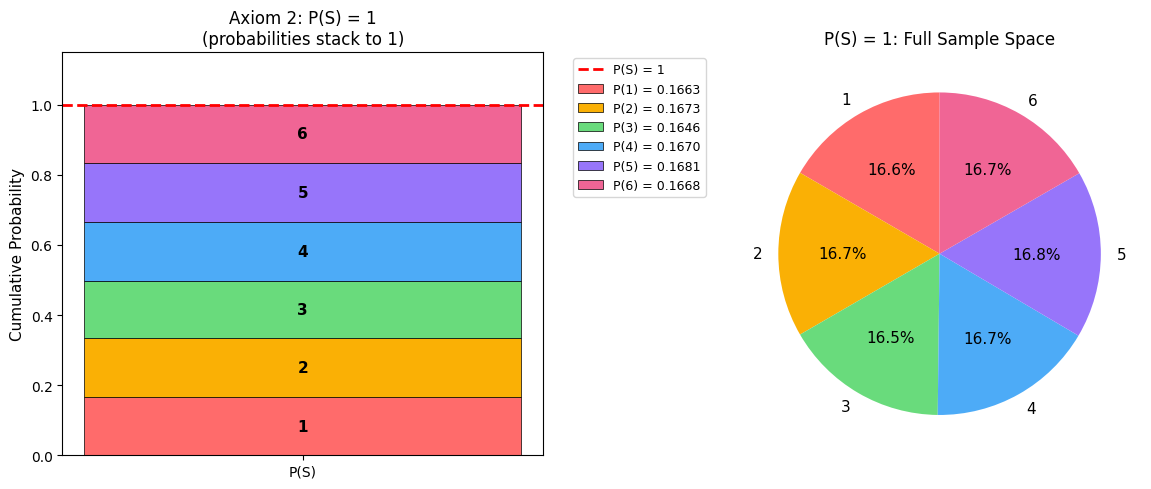

In [39]:
# Verify Axiom 2: P(S) = 1
# The sum of probabilities of all individual outcomes = 1
probs = [np.mean(rolls == outcome) for outcome in sorted(S_die)]
print("Axiom 2: P(S) = 1")
print("─" * 40)
for outcome, p in zip(sorted(S_die), probs):
    print(f"  P(roll = {outcome}) = {p:.4f}")
print(f"  {'─' * 25}")
print(f"  P(S) = Σ = {sum(probs):.4f} ≈ 1  ✓")

# --- Visualization: Axiom 2 — stacked bar showing P(S) = 1 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Stacked bar: each outcome stacks up to 1
bar_colors = ["#ff6b6b", "#fab005", "#69db7c", "#4dabf7", "#9775fa", "#f06595"]
bottom = 0
for i, (outcome, p) in enumerate(zip(sorted(S_die), probs)):
    ax1.bar(["P(S)"], [p], bottom=[bottom], color=bar_colors[i], edgecolor='black',
            linewidth=0.5, label=f"P({outcome}) = {p:.4f}")
    ax1.text(0, bottom + p / 2, f"{outcome}", ha='center', va='center', fontsize=11, fontweight='bold')
    bottom += p

ax1.axhline(y=1, color='red', linestyle='--', linewidth=2, label='P(S) = 1')
ax1.set_ylabel("Cumulative Probability", fontsize=11)
ax1.set_title("Axiom 2: P(S) = 1\n(probabilities stack to 1)", fontsize=12)
ax1.set_ylim(0, 1.15)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Pie chart
ax2.pie(probs, labels=[str(o) for o in sorted(S_die)], colors=bar_colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax2.set_title("P(S) = 1: Full Sample Space", fontsize=12)

plt.tight_layout()
plt.show()

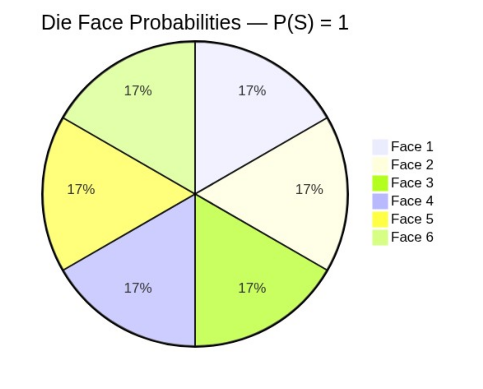

In [40]:
# Mermaid.js: Die face probabilities — P(S) = 1 (pie chart)
mm("""
pie title Die Face Probabilities — P(S) = 1
    "Face 1" : 1
    "Face 2" : 1
    "Face 3" : 1
    "Face 4" : 1
    "Face 5" : 1
    "Face 6" : 1
""")

### Axiom 3: Mutually Exclusive Events

If events $E$ and $F$ share **no outcomes** (they are **mutually exclusive**), then:

$$P(E \text{ or } F) = P(E) + P(F)$$

Two events are **mutually exclusive** if $E \cap F = \emptyset$

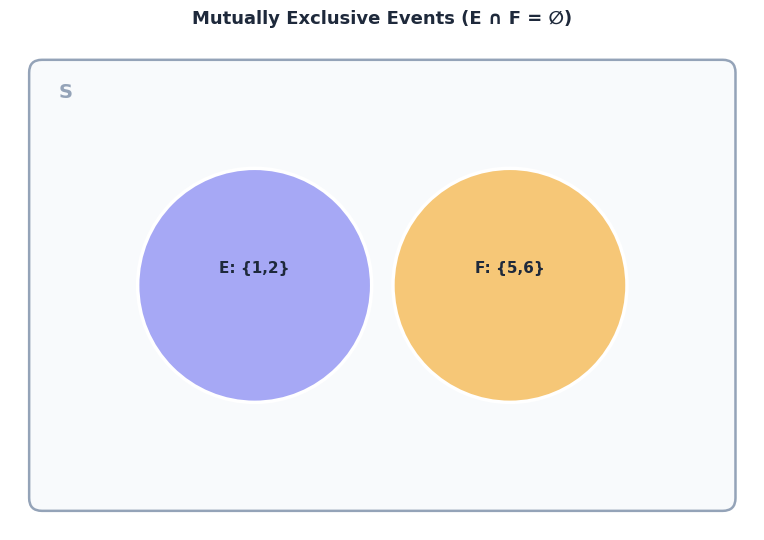

In [5]:
# Venn: mutually exclusive events (no overlap)
venn("""
venn-beta
  title "Mutually Exclusive Events (E ∩ F = ∅)"
  set E["E: {1,2}"]
  set F["F: {5,6}"]
""")

E = {1, 2}
F = {5, 6}
E ∩ F = set()  → mutually exclusive? True

Axiom 3: P(E or F) = P(E) + P(F) for mutually exclusive events
───────────────────────────────────────────────────────
  P(E)          = 0.3336
  P(F)          = 0.3349
  P(E) + P(F)   = 0.6684
  P(E or F)     = 0.6684
  Match? True  ✓


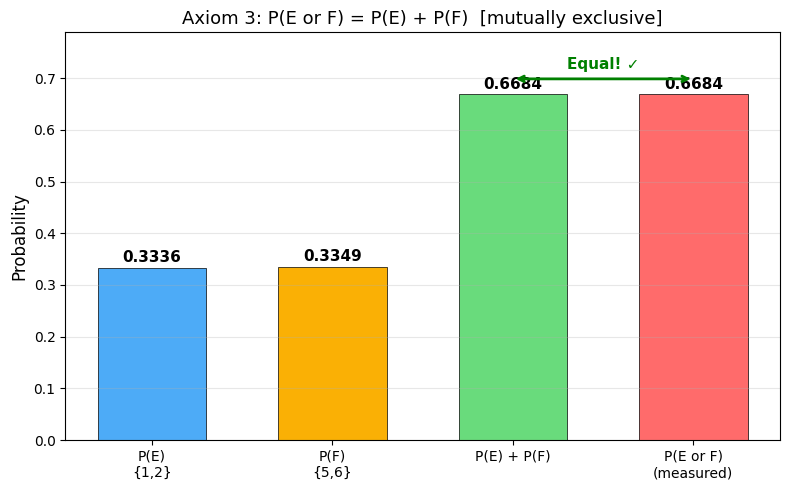

In [42]:
# Verify Axiom 3 with mutually exclusive events
# E = {1, 2}, F = {5, 6} → E ∩ F = ∅
E = {1, 2}
F = {5, 6}

print(f"E = {E}")
print(f"F = {F}")
print(f"E ∩ F = {E & F}  → mutually exclusive? {len(E & F) == 0}")
print()

p_E = np.mean(np.isin(rolls, list(E)))
p_F = np.mean(np.isin(rolls, list(F)))
p_E_or_F = np.mean(np.isin(rolls, list(E | F)))

print("Axiom 3: P(E or F) = P(E) + P(F) for mutually exclusive events")
print("─" * 55)
print(f"  P(E)          = {p_E:.4f}")
print(f"  P(F)          = {p_F:.4f}")
print(f"  P(E) + P(F)   = {p_E + p_F:.4f}")
print(f"  P(E or F)     = {p_E_or_F:.4f}")
print(f"  Match? {abs(p_E + p_F - p_E_or_F) < 0.001}  ✓")

# --- Visualization: Axiom 3 ---
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["P(E)\n{1,2}", "P(F)\n{5,6}", "P(E) + P(F)", "P(E or F)\n(measured)"]
values = [p_E, p_F, p_E + p_F, p_E_or_F]
colors = ["#4dabf7", "#fab005", "#69db7c", "#ff6b6b"]
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5, width=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Bracket showing equality
ax.annotate('', xy=(2, p_E + p_F + 0.03), xytext=(3, p_E_or_F + 0.03),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(2.5, p_E + p_F + 0.05, "Equal! ✓", ha='center', fontsize=11, color='green', fontweight='bold')

ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Axiom 3: P(E or F) = P(E) + P(F)  [mutually exclusive]", fontsize=13)
ax.set_ylim(0, max(values) + 0.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Non–Mutually Exclusive Events (Axiom 3 does NOT apply directly)

When events **overlap** ($E \cap F \neq \emptyset$), we cannot simply add probabilities:

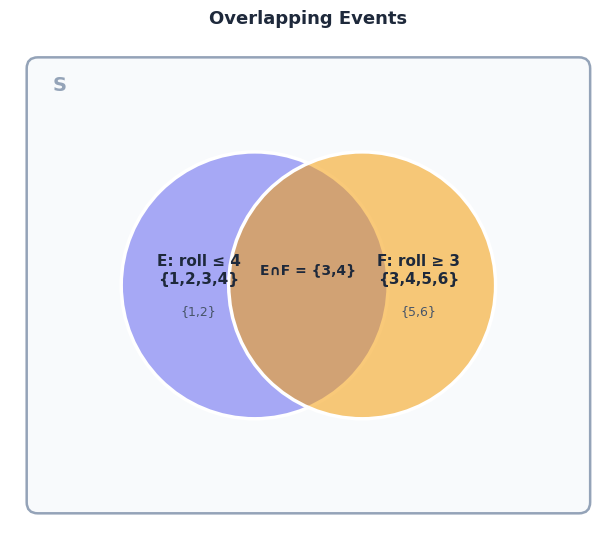

In [6]:
# Venn: overlapping events
venn("""
venn-beta
  title "Overlapping Events"
  set E["E: roll ≤ 4<br/>{1,2,3,4}"]
    text e1["{1,2}"]
  set F["F: roll ≥ 3<br/>{3,4,5,6}"]
    text f1["{5,6}"]
  union E,F["E∩F = {3,4}"]
""")

E = [1, 2, 3, 4]  (roll ≤ 4)
F = [3, 4, 5, 6]  (roll ≥ 3)
E ∩ F = [3, 4]  → NOT mutually exclusive!

P(E)              = 0.6651
P(F)              = 0.6664
P(E) + P(F)       = 1.3316  ← WRONG (double-counts overlap)
P(E ∩ F)          = 0.3316
P(E or F) actual  = 1.0000
P(E)+P(F)-P(E∩F)  = 1.0000  ← Correct!


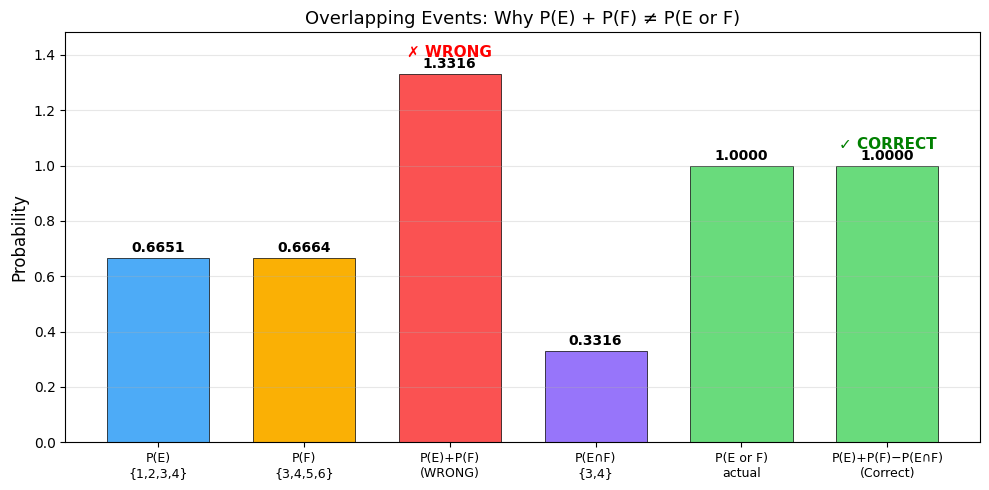

In [44]:
# Show why simple addition fails for overlapping events
E = {1, 2, 3, 4}  # roll ≤ 4
F = {3, 4, 5, 6}  # roll ≥ 3
intersection = E & F  # {3, 4}

print(f"E = {sorted(E)}  (roll ≤ 4)")
print(f"F = {sorted(F)}  (roll ≥ 3)")
print(f"E ∩ F = {sorted(intersection)}  → NOT mutually exclusive!")
print()

p_E = np.mean(np.isin(rolls, list(E)))
p_F = np.mean(np.isin(rolls, list(F)))
p_E_or_F = np.mean(np.isin(rolls, list(E | F)))
p_intersection = np.mean(np.isin(rolls, list(intersection)))

print(f"P(E)              = {p_E:.4f}")
print(f"P(F)              = {p_F:.4f}")
print(f"P(E) + P(F)       = {p_E + p_F:.4f}  ← WRONG (double-counts overlap)")
print(f"P(E ∩ F)          = {p_intersection:.4f}")
print(f"P(E or F) actual  = {p_E_or_F:.4f}")
print(f"P(E)+P(F)-P(E∩F)  = {p_E + p_F - p_intersection:.4f}  ← Correct!")

# --- Visualization: Overlapping events ---
fig, ax = plt.subplots(figsize=(10, 5))
labels = ["P(E)\n{1,2,3,4}", "P(F)\n{3,4,5,6}", "P(E)+P(F)\n(WRONG)", "P(E∩F)\n{3,4}", "P(E or F)\nactual", "P(E)+P(F)−P(E∩F)\n(Correct)"]
values = [p_E, p_F, p_E + p_F, p_intersection, p_E_or_F, p_E + p_F - p_intersection]
colors = ["#4dabf7", "#fab005", "#fa5252", "#9775fa", "#69db7c", "#69db7c"]
bars = ax.bar(range(len(labels)), values, color=colors, edgecolor='black', linewidth=0.5, width=0.7)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Mark wrong vs correct
ax.text(2, values[2] + 0.06, "✗ WRONG", ha='center', fontsize=11, color='red', fontweight='bold')
ax.text(5, values[5] + 0.06, "✓ CORRECT", ha='center', fontsize=11, color='green', fontweight='bold')

ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Overlapping Events: Why P(E) + P(F) ≠ P(E or F)", fontsize=13)
ax.set_ylim(0, max(values) + 0.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 4. Provable Identities

These are corollaries that follow directly from the three axioms.

### Identity 1: Complement Rule

$$P(E^C) = 1 - P(E)$$

The probability of event $E$ **not** happening equals $1$ minus the probability of $E$ happening.

**Proof:**

1. $P(S) = P(E \text{ or } E^C)$ — since $E$ or $E^C$ covers every outcome in $S$
2. $P(S) = P(E) + P(E^C)$ — since $E$ and $E^C$ are mutually exclusive (Axiom 3)
3. $1 = P(E) + P(E^C)$ — by Axiom 2
4. $P(E^C) = 1 - P(E)$ — rearranging

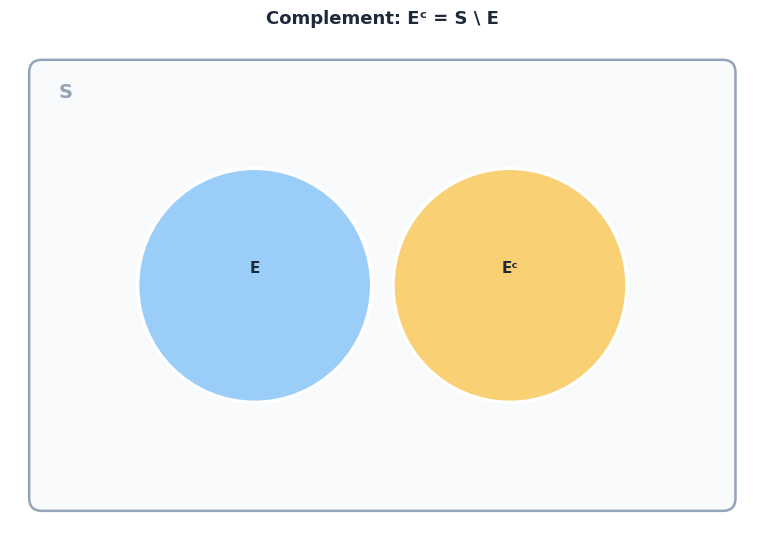

In [7]:
# Venn: complement
venn("""
venn-beta
  title "Complement: Eᶜ = S \\ E"
  set E["E"]
  set Ec["Eᶜ"]
  style E fill:#4dabf7
  style Ec fill:#fab005
""")

Identity 1: P(Eᶜ) = 1 - P(E)
────────────────────────────────────────
E  = [1, 2, 3]
Eᶜ = [4, 5, 6]

P(E)      = 0.4982
P(Eᶜ)     = 0.5018
1 - P(E)  = 0.5018
P(E) + P(Eᶜ) = 1.0000 ≈ 1  ✓


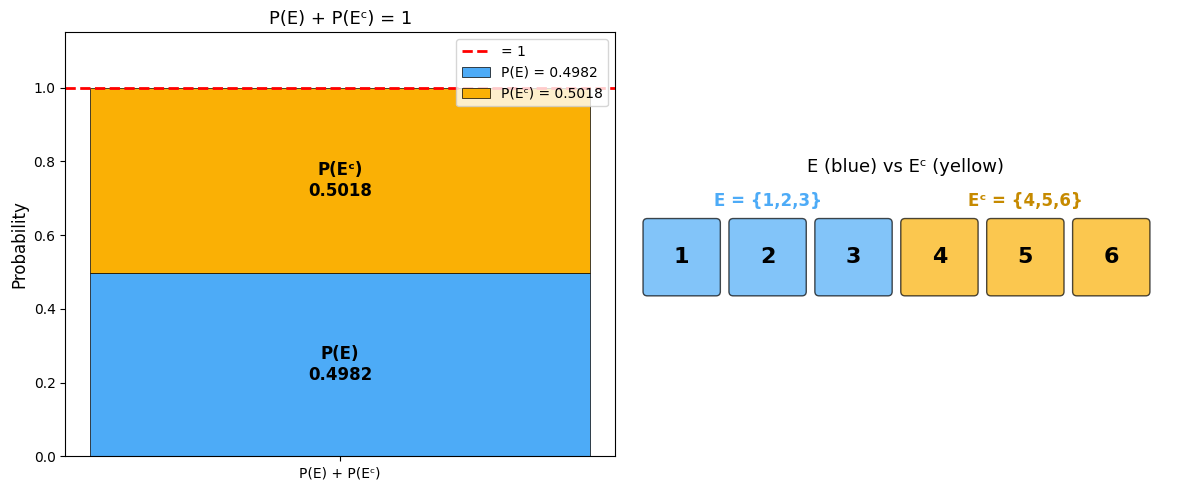

In [46]:
# Verify Identity 1: P(E^C) = 1 - P(E)
E = {1, 2, 3}  # roll ≤ 3
E_complement = S_die - E  # {4, 5, 6}

p_E = np.mean(np.isin(rolls, list(E)))
p_Ec = np.mean(np.isin(rolls, list(E_complement)))

print("Identity 1: P(Eᶜ) = 1 - P(E)")
print("─" * 40)
print(f"E  = {sorted(E)}")
print(f"Eᶜ = {sorted(E_complement)}")
print(f"")
print(f"P(E)      = {p_E:.4f}")
print(f"P(Eᶜ)     = {p_Ec:.4f}")
print(f"1 - P(E)  = {1 - p_E:.4f}")
print(f"P(E) + P(Eᶜ) = {p_E + p_Ec:.4f} ≈ 1  ✓")

# --- Visualization: Complement Rule ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Stacked bar: P(E) + P(Eᶜ) = 1
ax1.bar(["P(E) + P(Eᶜ)"], [p_E], color="#4dabf7", edgecolor='black', linewidth=0.5, label=f"P(E) = {p_E:.4f}")
ax1.bar(["P(E) + P(Eᶜ)"], [p_Ec], bottom=[p_E], color="#fab005", edgecolor='black', linewidth=0.5, label=f"P(Eᶜ) = {p_Ec:.4f}")
ax1.axhline(y=1, color='red', linestyle='--', linewidth=2, label="= 1")
ax1.text(0, p_E / 2, f"P(E)\n{p_E:.4f}", ha='center', va='center', fontsize=12, fontweight='bold')
ax1.text(0, p_E + p_Ec / 2, f"P(Eᶜ)\n{p_Ec:.4f}", ha='center', va='center', fontsize=12, fontweight='bold')
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_title("P(E) + P(Eᶜ) = 1", fontsize=13)
ax1.set_ylim(0, 1.15)
ax1.legend(loc='upper right')

# Die faces colored by E vs Eᶜ
for i, face in enumerate(range(1, 7)):
    in_E = face in E
    color = "#4dabf7" if in_E else "#fab005"
    rect = patches.FancyBboxPatch((i * 1.0 + 0.1, 0.2), 0.8, 0.8,
                                   boxstyle="round,pad=0.05", facecolor=color, alpha=0.7, edgecolor='black')
    ax2.add_patch(rect)
    ax2.text(i * 1.0 + 0.5, 0.6, str(face), ha='center', va='center', fontsize=16, fontweight='bold')

ax2.text(1.5, 1.2, "E = {1,2,3}", ha='center', fontsize=12, color="#4dabf7", fontweight='bold')
ax2.text(4.5, 1.2, "Eᶜ = {4,5,6}", ha='center', fontsize=12, color="#c68a00", fontweight='bold')
ax2.set_xlim(-0.1, 6.3)
ax2.set_ylim(0, 1.5)
ax2.set_aspect('equal')
ax2.set_title("E (blue) vs Eᶜ (yellow)", fontsize=13)
ax2.axis('off')

plt.tight_layout()
plt.show()

### Identity 2: Subset Rule

$$\text{If } E \subseteq F, \text{ then } P(E) \leq P(F)$$

If every outcome in $E$ is also in $F$, then $F$ is at least as likely as $E$.

This is intuitive: a larger set of outcomes can only be more (or equally) likely.

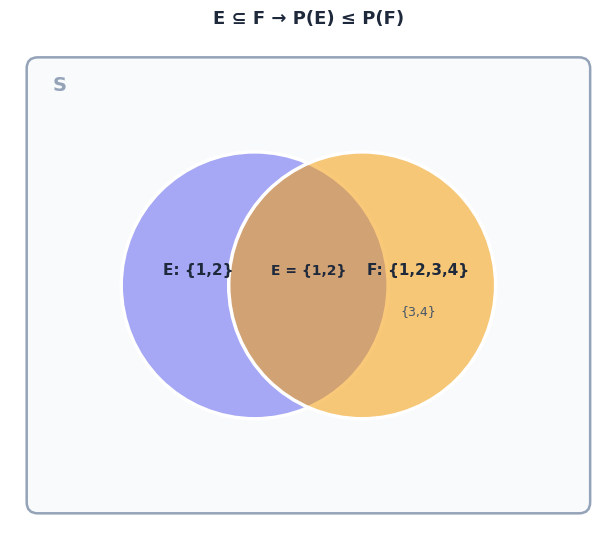

In [8]:
# Venn: subset (E ⊆ F shown as overlapping)
venn("""
venn-beta
  title "E ⊆ F → P(E) ≤ P(F)"
  set E["E: {1,2}"]
  set F["F: {1,2,3,4}"]
    text f1["{3,4}"]
  union E,F["E = {1,2}"]
""")

E = [1, 2]
F = [1, 2, 3, 4]
E ⊆ F ? True

Identity 2: If E ⊆ F, then P(E) ≤ P(F)
────────────────────────────────────────
P(E) = 0.3336
P(F) = 0.6651
P(E) ≤ P(F) ? True  ✓


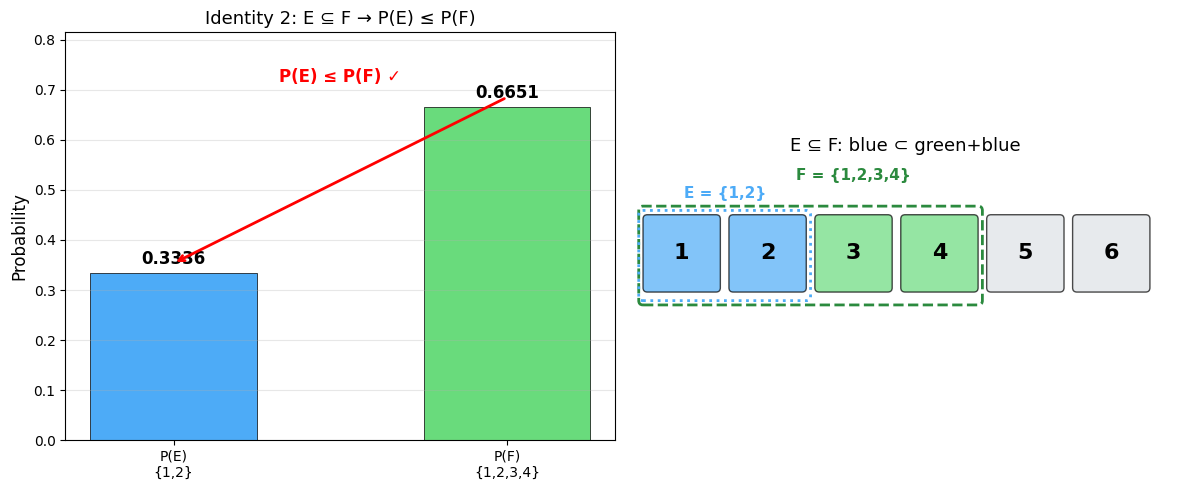

In [48]:
# Verify Identity 2: If E ⊆ F, then P(E) ≤ P(F)
E = {1, 2}
F = {1, 2, 3, 4}

print(f"E = {sorted(E)}")
print(f"F = {sorted(F)}")
print(f"E ⊆ F ? {E.issubset(F)}")
print()

p_E = np.mean(np.isin(rolls, list(E)))
p_F = np.mean(np.isin(rolls, list(F)))

print("Identity 2: If E ⊆ F, then P(E) ≤ P(F)")
print("─" * 40)
print(f"P(E) = {p_E:.4f}")
print(f"P(F) = {p_F:.4f}")
print(f"P(E) ≤ P(F) ? {p_E <= p_F}  ✓")

# --- Visualization: Subset Rule ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart comparing P(E) vs P(F)
bars = ax1.bar(["P(E)\n{1,2}", "P(F)\n{1,2,3,4}"], [p_E, p_F],
               color=["#4dabf7", "#69db7c"], edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars, [p_E, p_F]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.annotate('', xy=(0, p_E + 0.02), xytext=(1, p_F + 0.02),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax1.text(0.5, max(p_E, p_F) + 0.05, "P(E) ≤ P(F) ✓", ha='center', fontsize=12, color='red', fontweight='bold')
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_title("Identity 2: E ⊆ F → P(E) ≤ P(F)", fontsize=13)
ax1.set_ylim(0, max(p_E, p_F) + 0.15)
ax1.grid(axis='y', alpha=0.3)

# Die faces showing E inside F
for i, face in enumerate(range(1, 7)):
    in_E = face in E
    in_F = face in F
    if in_E:
        color = "#4dabf7"  # E (also in F)
    elif in_F:
        color = "#69db7c"  # F only
    else:
        color = "#dee2e6"  # neither
    rect = patches.FancyBboxPatch((i * 1.0 + 0.1, 0.2), 0.8, 0.8,
                                   boxstyle="round,pad=0.05", facecolor=color, alpha=0.7, edgecolor='black')
    ax2.add_patch(rect)
    ax2.text(i * 1.0 + 0.5, 0.6, str(face), ha='center', va='center', fontsize=16, fontweight='bold')

ax2.text(1.0, 1.25, "E = {1,2}", ha='center', fontsize=11, color="#4dabf7", fontweight='bold')
ax2.text(2.5, 1.45, "F = {1,2,3,4}", ha='center', fontsize=11, color="#2b8a3e", fontweight='bold')
# Draw bracket for F
bracket = patches.FancyBboxPatch((0.05, 0.05), 3.9, 1.05, boxstyle="round,pad=0.05",
                                  edgecolor="#2b8a3e", facecolor='none', linewidth=2, linestyle='--')
ax2.add_patch(bracket)
# Draw bracket for E
bracket_e = patches.FancyBboxPatch((0.05, 0.1), 1.9, 0.95, boxstyle="round,pad=0.05",
                                    edgecolor="#4dabf7", facecolor='none', linewidth=2, linestyle=':')
ax2.add_patch(bracket_e)

ax2.set_xlim(-0.1, 6.3)
ax2.set_ylim(-0.1, 1.7)
ax2.set_aspect('equal')
ax2.set_title("E ⊆ F: blue ⊂ green+blue", fontsize=13)
ax2.axis('off')

plt.tight_layout()
plt.show()

---

## 5. Probability via Simulation

For complex problems where analytical solutions are hard, we can approximate probabilities via **simulation**.

If simulations generate believable trials from the sample space, then:

$$P(E) \approx \frac{\text{simulations producing } E}{\text{total simulations}}$$

As the number of simulations $\to \infty$, the estimate becomes more accurate.

Simulation: P(at least one head in two coin flips)
──────────────────────────────────────────────────
  Sample space S = {HH, HT, TH, TT}
  Event E = {HH, HT, TH}

  Analytical: P(E) = 3/4 = 0.7500
  Simulated:  P(E) ≈ 0.7508  (100,000 trials)


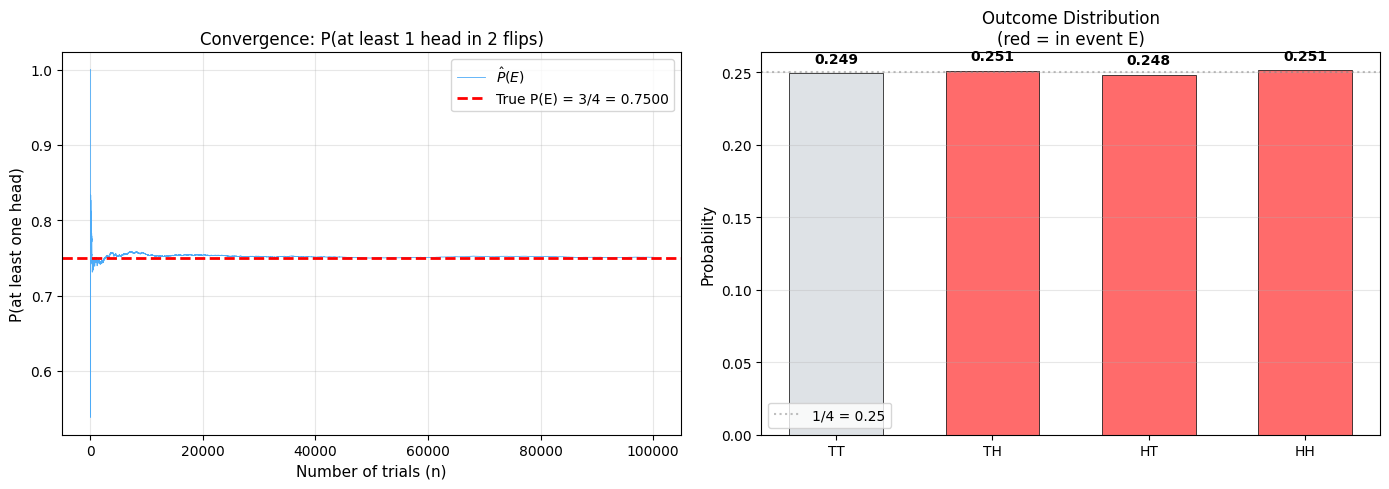

In [49]:
# Simulation: Two coin flips — P(at least one head)
n_simulations = 100_000

# Simulate two coin flips (0 = Tails, 1 = Heads)
flip1 = np.random.randint(0, 2, size=n_simulations)
flip2 = np.random.randint(0, 2, size=n_simulations)

# Event: at least one head
at_least_one_head = (flip1 == 1) | (flip2 == 1)
p_simulated = np.mean(at_least_one_head)

# Analytical: S = {HH, HT, TH, TT}, E = {HH, HT, TH} → P(E) = 3/4
p_analytical = 3 / 4

print("Simulation: P(at least one head in two coin flips)")
print("─" * 50)
print(f"  Sample space S = {{HH, HT, TH, TT}}")
print(f"  Event E = {{HH, HT, TH}}")
print(f"")
print(f"  Analytical: P(E) = 3/4 = {p_analytical:.4f}")
print(f"  Simulated:  P(E) ≈ {p_simulated:.4f}  ({n_simulations:,} trials)")

# --- Visualization: Convergence plot for coin flips ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convergence plot
cumulative = np.cumsum(at_least_one_head)
trial_nums = np.arange(1, n_simulations + 1)
running_prob = cumulative / trial_nums

ax1.plot(trial_nums, running_prob, linewidth=0.6, color="#4dabf7", label=r"$\hat{P}(E)$")
ax1.axhline(y=p_analytical, color="red", linestyle="--", linewidth=2, label=f"True P(E) = 3/4 = {p_analytical:.4f}")
ax1.set_xlabel("Number of trials (n)", fontsize=11)
ax1.set_ylabel("P(at least one head)", fontsize=11)
ax1.set_title("Convergence: P(at least 1 head in 2 flips)", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Outcome distribution bar chart
outcomes = flip1 * 2 + flip2  # 0=TT, 1=TH, 2=HT, 3=HH
outcome_labels = ["TT", "TH", "HT", "HH"]
outcome_counts = [np.sum(outcomes == i) for i in range(4)]
outcome_probs = [c / n_simulations for c in outcome_counts]
bar_colors = ["#dee2e6", "#ff6b6b", "#ff6b6b", "#ff6b6b"]  # gray=not in E, red=in E

bars = ax2.bar(outcome_labels, outcome_probs, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.6)
for bar, val in zip(bars, outcome_probs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5, label='1/4 = 0.25')
ax2.set_ylabel("Probability", fontsize=11)
ax2.set_title("Outcome Distribution\n(red = in event E)", fontsize=12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

## Summary

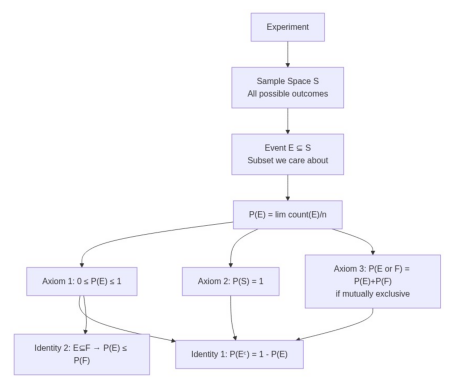

In [50]:
# Summary flowchart
mm("""
graph TD
    A["Experiment"] --> B["Sample Space S<br/>All possible outcomes"]
    B --> C["Event E ⊆ S<br/>Subset we care about"]
    C --> D["P(E) = lim count(E)/n"]
    D --> E1["Axiom 1: 0 ≤ P(E) ≤ 1"]
    D --> E2["Axiom 2: P(S) = 1"]
    D --> E3["Axiom 3: P(E or F) = P(E)+P(F)<br/>if mutually exclusive"]
    E1 --> F1["Identity 1: P(Eᶜ) = 1 - P(E)"]
    E3 --> F1
    E2 --> F1
    E1 --> F2["Identity 2: E⊆F → P(E) ≤ P(F)"]
""")

| Concept | Key Formula |
|---|---|
| Definition of Probability | $P(E) = \lim_{n \to \infty} \frac{\text{count}(E)}{n}$ |
| Axiom 1 | $0 \leq P(E) \leq 1$ |
| Axiom 2 | $P(S) = 1$ |
| Axiom 3 (mutually exclusive) | $P(E \text{ or } F) = P(E) + P(F)$ |
| Complement | $P(E^C) = 1 - P(E)$ |
| Subset | $E \subseteq F \Rightarrow P(E) \leq P(F)$ |